# Final Evaluation — Phase 1: Qwen-Bailian Workload Characterization

This notebook **consumes** the CPU-only analysis written by
`experiments/scripts/analyze_qwen_bailian_workload.py`. It does not reimplement
the statistics, does not run a GPU workload, and does not modify replay results.

The script is the source of truth. Re-run it before refreshing these tables if
the JSON or figures are missing.

## 1. Experiment constants

In [1]:
from pathlib import Path

from IPython.display import Image, Markdown, display
import pandas as pd

PROJECT_ROOT = Path.home() / "kv_cache_project"
if not (PROJECT_ROOT / "experiments").exists():
    PROJECT_ROOT = Path.cwd()

STATISTICS_JSON = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "qwen_bailian_analysis"
    / "workload_statistics.json"
)
FIGURES_DIR = (
    PROJECT_ROOT / "experiments" / "figures" / "qwen_bailian_workload"
)
TRACE_PATH = (
    PROJECT_ROOT
    / "datasets"
    / "qwen_bailian"
    / "raw"
    / "qwen_traceA_blksz_16.jsonl"
)

BLOCK_SIZE_TOKENS = 16
HOT_BYTES_PER_BLOCK = 1_835_008
WARM_BYTES_PER_SLOT = 946_176
TOTAL_KV_BUDGET_BYTES = 4 * 1024**3
SEED = 0
MAX_INPUT_LENGTHS = [1024, 2048]
TIME_SCALES = [1.0, 0.01, 0.005]
SESSION_COUNTS = [25, 50, 100, 250, 542, 750, 1000, 1500]
WARM_POOL_BLOCKS = [512, 1024]
PRIMARY_DEMOTION_START = 0.80
PRIMARY_DEMOTION_STOP = 0.65
REQUEST_TYPE = "text"
MIN_TURNS = 2

print("Project root:", PROJECT_ROOT)
print("Statistics JSON:", STATISTICS_JSON)
print("Figures directory:", FIGURES_DIR)
print("Trace path:", TRACE_PATH)
print("Persistent KV budget (bytes):", TOTAL_KV_BUDGET_BYTES)

Project root: /home/shani.dayan/kv_cache_project
Statistics JSON: /home/shani.dayan/kv_cache_project/experiments/results/qwen_bailian_analysis/workload_statistics.json
Figures directory: /home/shani.dayan/kv_cache_project/experiments/figures/qwen_bailian_workload
Trace path: /home/shani.dayan/kv_cache_project/datasets/qwen_bailian/raw/qwen_traceA_blksz_16.jsonl
Persistent KV budget (bytes): 4294967296


## 2. Load `workload_statistics.json`

In [2]:
import json

if not STATISTICS_JSON.exists():
    raise FileNotFoundError(
        "Missing workload statistics. Run:\n"
        "PYTHONPATH=external/vllm:. python \\\n"
        "  experiments/scripts/analyze_qwen_bailian_workload.py \\\n"
        f"  --trace {TRACE_PATH}"
    )

with STATISTICS_JSON.open(encoding="utf-8") as source:
    stats = json.load(source)

constants = stats["analysis_constants"]
schema = stats["trace_schema_interpretation"]
counts = stats["trace_counts"]
capacity = stats["equal_memory_capacity"]["configurations"]
recommendation = stats["recommendation"]

assert constants["block_size_tokens"] == BLOCK_SIZE_TOKENS
assert constants["hot_bytes_per_block"] == HOT_BYTES_PER_BLOCK
assert constants["warm_bytes_per_slot"] == WARM_BYTES_PER_SLOT
assert constants["total_kv_budget_bytes"] == TOTAL_KV_BUDGET_BYTES
assert schema["input_length_semantics"] == "cumulative_context_tokens"

print("Schema version:", stats["schema_version"])
print("Input-length semantics:", schema["input_length_semantics"])
print("Session identifier:", schema["session_identifier"])
print("Eligible pool:", recommendation["eligible_session_pool"])

Schema version: 1.1
Input-length semantics: cumulative_context_tokens
Session identifier: root chat_id (parent_chat_id == -1). The trace has no verified user identifier, so this analysis reports sessions, not users.
Eligible pool: 2437


## 3. Dataset statistics

In [3]:
def show_table(title, rows):
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))


show_table(
    "Trace-level counts",
    [
        {
            "total_non_empty_rows": counts["total_non_empty_rows"],
            "valid_rows": counts["valid_rows"],
            "complete_sessions": counts["complete_sessions"],
            "incomplete_sessions": counts["incomplete_sessions"],
            "single_turn_sessions": counts["single_turn_sessions"],
            "multi_turn_sessions": counts["multi_turn_sessions"],
            "text_only_multi_turn_sessions": counts[
                "text_only_multi_turn_sessions"
            ],
            "filtered_max_input_1024": counts[
                "filtered_text_only_multi_turn_sessions"
            ]["1024"],
            "filtered_max_input_2048": counts[
                "filtered_text_only_multi_turn_sessions"
            ]["2048"],
            "malformed_or_rejected_rows": counts[
                "malformed_or_rejected_rows"
            ],
        }
    ],
)

show_table(
    "Request modalities",
    [
        {"type": name, "rows": value}
        for name, value in counts["request_type_counts"].items()
    ],
)

eligible_stats = stats["session_statistics"][
    "text_only_multi_turn_max_input_1024"
]
distribution_rows = []
for name in (
    "turns_per_session",
    "first_input_length",
    "final_input_length",
    "max_input_length",
    "output_length_per_turn",
    "total_output_length_per_session",
    "total_requests_per_session",
    "trace_duration_seconds_per_session",
    "inter_turn_gap_seconds",
):
    row = {"metric": name}
    row.update(eligible_stats[name])
    distribution_rows.append(row)
show_table(
    "Eligible session distributions (text-only, multi-turn, max input 1024)",
    distribution_rows,
)

show_table(
    "Sessions returning after idle gaps",
    [
        {"gap": name, **values}
        for name, values in eligible_stats["sessions_returning_after"].items()
    ],
)

retention_rows = []
for scale, values in stats["arrival_and_retention"]["by_time_scale"].items():
    retention_rows.append(
        {
            "time_scale": values["time_scale"],
            "requests_per_simulated_second": values[
                "requests_arriving_per_simulated_second"
            ],
            "peak_arrivals_per_1s_bucket": values[
                "peak_arrivals_in_one_second_buckets"
            ],
            "peak_retained_sessions": values["peak_retained_sessions"],
            "median_retained_sessions": values["median_retained_sessions"],
            "p95_retained_sessions": values["p95_retained_sessions"],
            "peak_estimated_hot_blocks": values["peak_estimated_hot_blocks"],
        }
    )
show_table(
    "Arrival and retained-session overlap (eligible pool)",
    retention_rows,
)
display(
    Markdown(
        "Retained sessions are conversations holding KV between the first and "
        "final turn. They are **not** GPU inference concurrency. Measured "
        "runtime concurrency requires a GPU replay."
    )
)

selection_rows = []
for count, item in stats["workload_selections"].items():
    selection_rows.append(
        {
            "requested_sessions": int(count),
            "selected_sessions": item["selected_session_count"],
            "selected_requests": item["selected_request_count"],
            "total_context_tokens": item["total_context_token_demand"],
            "complete_blocks": item["complete_block_demand"],
            "incomplete_tail_blocks": item["incomplete_tail_block_demand"],
            "peak_estimated_hot_blocks": item["peak_estimated_hot_blocks"],
            "peak_retained_sessions": item["peak_retained_sessions"],
            "exceeds_all_hot_2340": item["peak_exceeds_all_hot_capacity"],
            "excess_blocks": item["excess_hot_blocks"],
            "excess_percent": item["excess_hot_percent"],
            "selection_sha256": item["selection_sha256"][:12] + "…",
        }
    )
show_table("Selected replay workloads", selection_rows)

capacity_rows = []
for name, item in capacity.items():
    capacity_rows.append(
        {
            "configuration": name,
            "hot_blocks": item["hot_blocks"],
            "warm_pool_blocks": item["warm_pool_blocks"],
            "total_logical_blocks": item["total_logical_blocks"],
            "logical_token_capacity": item["logical_token_capacity"],
            "gain_over_all_hot_percent": item[
                "capacity_gain_over_all_hot_percent"
            ],
            "warm_storage_bytes": item["warm_storage_bytes"],
            "map_bytes": item["map_bytes"],
            "slot_table_bytes": item["slot_table_bytes"],
            "actual_persistent_kv_bytes": item["actual_persistent_kv_bytes"],
            "budget_slack_bytes": item["budget_slack_bytes"],
            "within_4_gib": item["within_total_budget"],
        }
    )
show_table("Equal-memory 4 GiB capacity", capacity_rows)

policy_rows = []
for row in stats.get("policy_pressure_table", []):
    policy_rows.append(
        {
            "requested_sessions": row["requested_sessions"],
            "mixed_configuration": row["mixed_configuration"],
            "start": row["start_utilization"],
            "stop": row["stop_utilization"],
            "hot_start_threshold_blocks": row["mixed_hot_start_threshold_blocks"],
            "hot_stop_target_blocks": row["mixed_hot_stop_target_blocks"],
            "peak_retained_blocks": row["peak_estimated_retained_blocks"],
            "blocks_to_demote_to_stop": row["projected_blocks_to_demote_to_stop"],
            "warm_can_hold": row["warm_pool_can_hold_demotion"],
            "hot_after_max_demotion": row["projected_hot_blocks_after_max_demotion"],
            "hot_util_after_max_demotion": row[
                "projected_hot_utilization_after_max_demotion"
            ],
            "would_start_demotion": row["policy_would_start_demotion"],
            "exceeds_all_hot": row["all_hot_capacity_exceeded"],
            "exceeds_mixed_total": row["mixed_total_logical_capacity_exceeded"],
        }
    )
show_table("Policy-aware Mixed pressure estimates", policy_rows)

show_table(
    "Smallest timestamp-ordered prefixes reaching capacity fractions",
    stats.get("prefix_peak_targets", []),
)

high = stats.get("high_load_prefix_search", {})
show_table("High-load prefix search", [high] if high else [])

bias = stats.get("selection_bias", {})
bias_rows = []
for count, item in bias.get("prefixes", {}).items():
    for metric, values in item.get("metrics", {}).items():
        bias_rows.append(
            {
                "prefix_sessions": int(count),
                "metric": metric,
                "prefix_median": values["prefix"]["median"],
                "pool_median": values["eligible_pool"]["median"],
                "median_relative_diff": values["median_relative_diff"],
                "prefix_mean": values["prefix"]["mean"],
                "pool_mean": values["eligible_pool"]["mean"],
                "mean_relative_diff": values["mean_relative_diff"],
                "material": values["material"],
            }
        )
show_table("Timestamp-ordered prefix vs eligible-pool bias", bias_rows)
display(Markdown(bias.get("interpretation", "")))
display(Markdown(bias.get("follow_up", "")))

### Trace-level counts

,total_non_empty_rows,valid_rows,complete_sessions,incomplete_sessions,single_turn_sessions,multi_turn_sessions,text_only_multi_turn_sessions,filtered_max_input_1024,filtered_max_input_2048,malformed_or_rejected_rows
0,43058,43058,23101,0,14089,9012,6739,2437,4930,0


### Request modalities

,type,rows
0,text,31744
1,image,1617
2,search,8187
3,file,1510


### Eligible session distributions (text-only, multi-turn, max input 1024)

...

,preferred_peak_min_blocks,preferred_peak_max_blocks,all_hot_capacity_blocks,mixed_total_logical_blocks,range_satisfied,session_count,peak_estimated_hot_blocks,peak_retained_sessions,clearly_above_all_hot_capacity,below_mixed_total_logical_capacity,closest_below_session_count,closest_below_peak_estimated_hot_blocks,closest_above_session_count,closest_above_peak_estimated_hot_blocks,note
0,2600,2750,2340,2836,True,1431,2660,163,True,True,1427,2591,1435,2765,Timestamp-ordered prefix of 1431 sessions has ...


### Timestamp-ordered prefix vs eligible-pool bias

,prefix_sessions,metric,prefix_median,pool_median,median_relative_diff,prefix_mean,pool_mean,mean_relative_diff,material
0,25,turns_per_session,2.000,2.000,0.000000,2.520000,2.369717,0.063418,False
1,25,final_input_length,584.000,586.000,-0.003413,592.080000,604.027493,-0.019780,False
2,25,inter_turn_gap_seconds,74.172,73.923,0.003368,361.467500,269.307671,0.342210,True
3,50,turns_per_session,2.000,2.000,0.000000,2.500000,2.369717,0.054978,False
4,50,final_input_length,584.000,586.000,-0.003413,597.500000,604.027493,-0.010807,False
5,50,inter_turn_gap_seconds,66.666,73.923,-0.098170,329.871533,269.307671,0.224887,True
6,100,turns_per_session,2.000,2.000,0.000000,2.510000,2.369717,0.059198,False
7,100,final_input_length,621.000,586.000,0.059727,633.340000,604.027493,0.048528,False
8,100,inter_turn_gap_seconds,80.657,73.923,0.091095,365.071172,269.307671,0.355591,True
9,250,turns_per_session,2.000,2.000,0.000000,2.464000,2.369717,0.039787,False


Timestamp-ordered prefixes differ materially from the complete eligible pool at the 15% relative-difference threshold: 25 sessions on inter_turn_gap_seconds; 50 sessions on inter_turn_gap_seconds; 100 sessions on inter_turn_gap_seconds; 250 sessions on inter_turn_gap_seconds.

The recommended high-load prefix is not materially biased versus the eligible pool. A peak-window or deterministic sampled selection can be considered for the earliest small/medium prefixes if gap-tail matching matters; this analysis does not redesign the timestamp-ordered prefix rule.

## 4. Workload figures

Figures are generated by the analysis script, not by this notebook.

**turns per session**

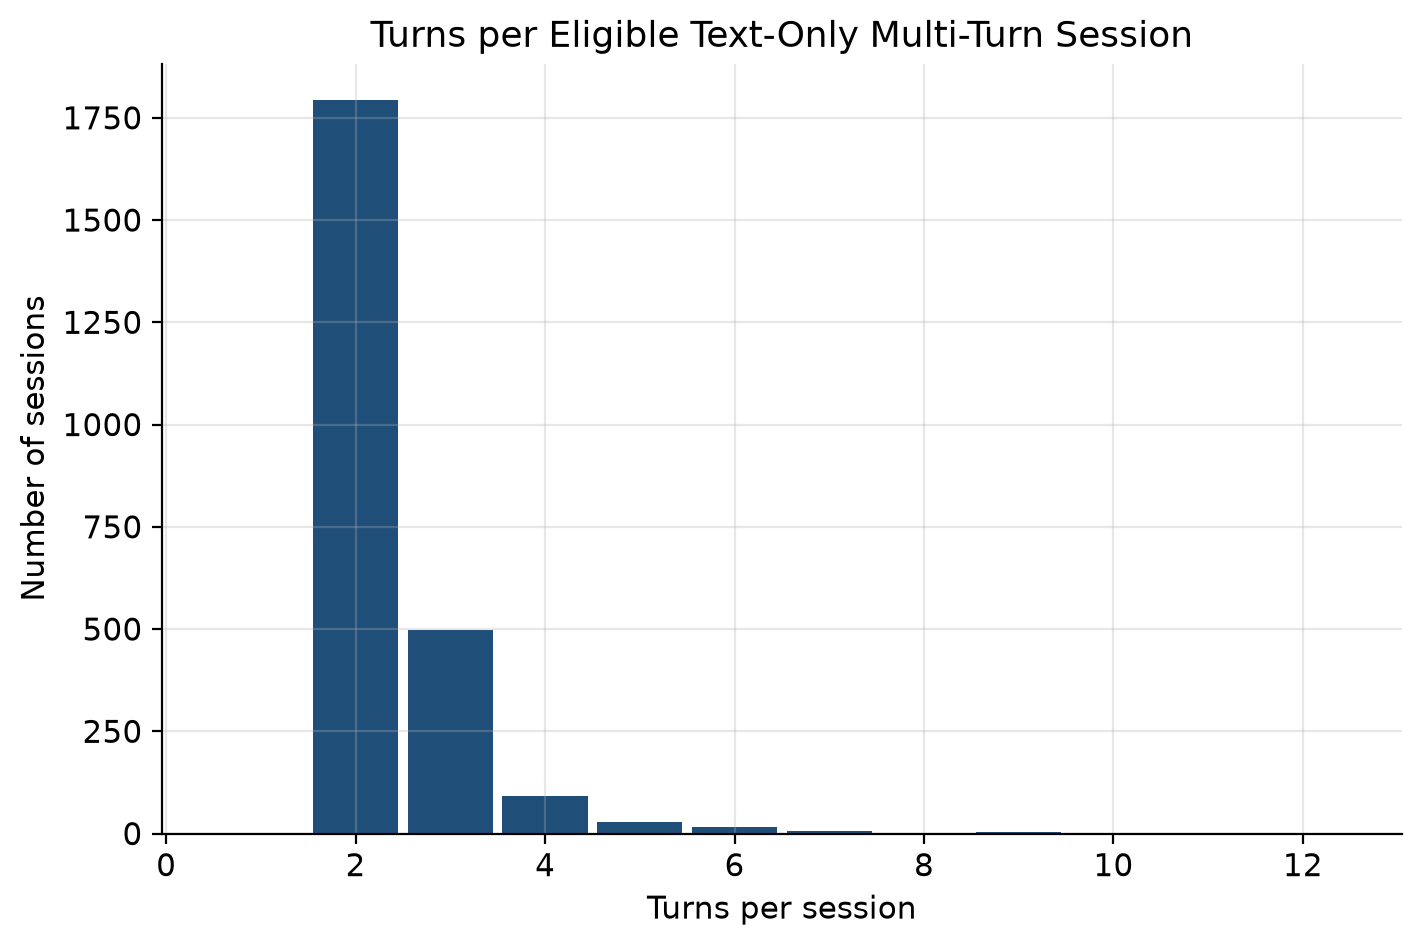

**context length distribution**

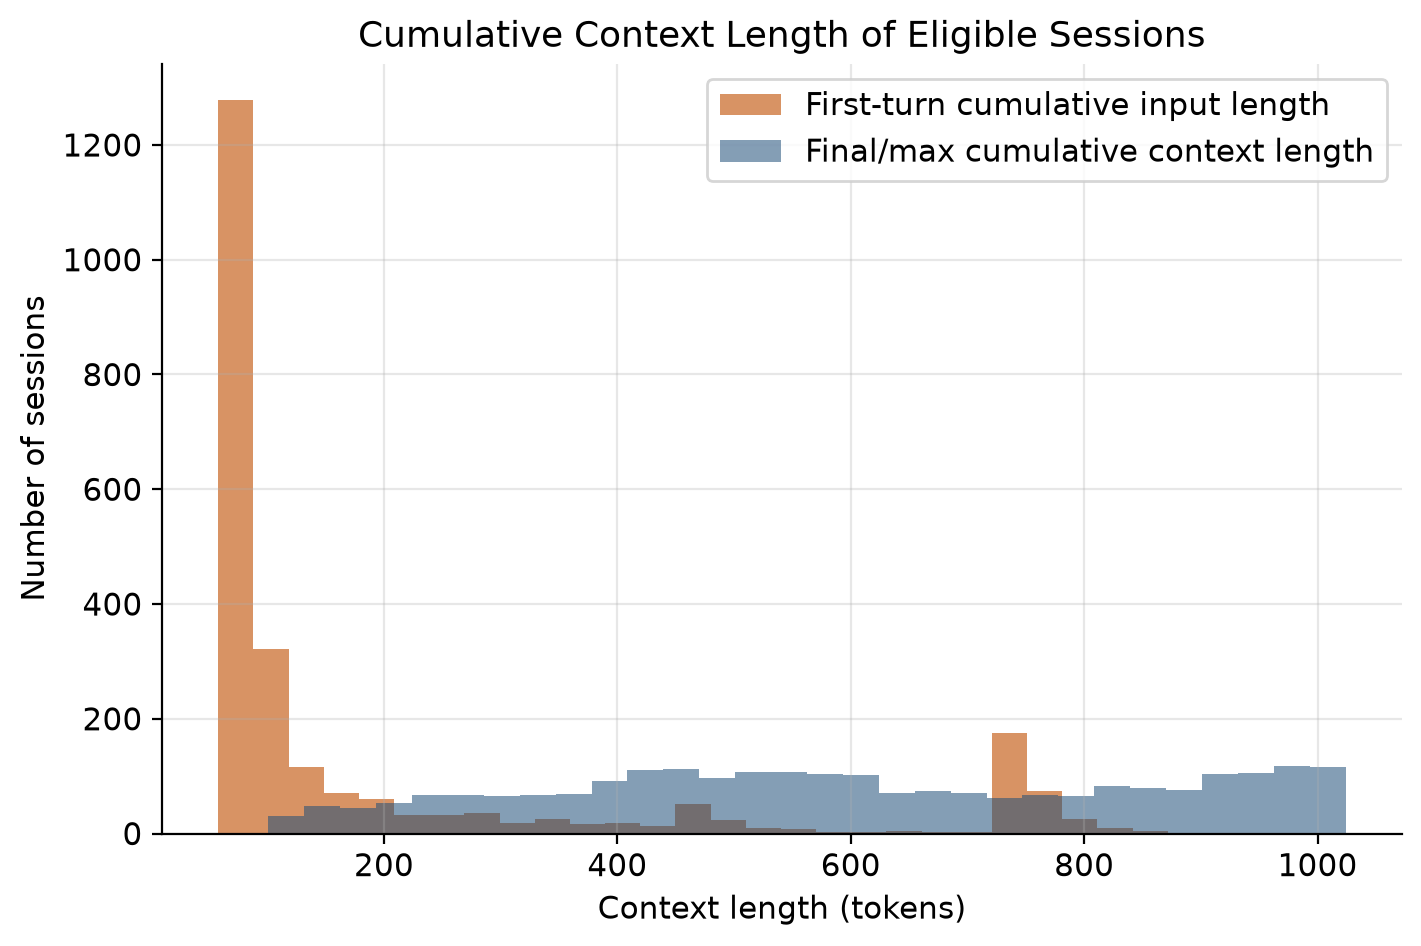

**inter turn gap distribution**

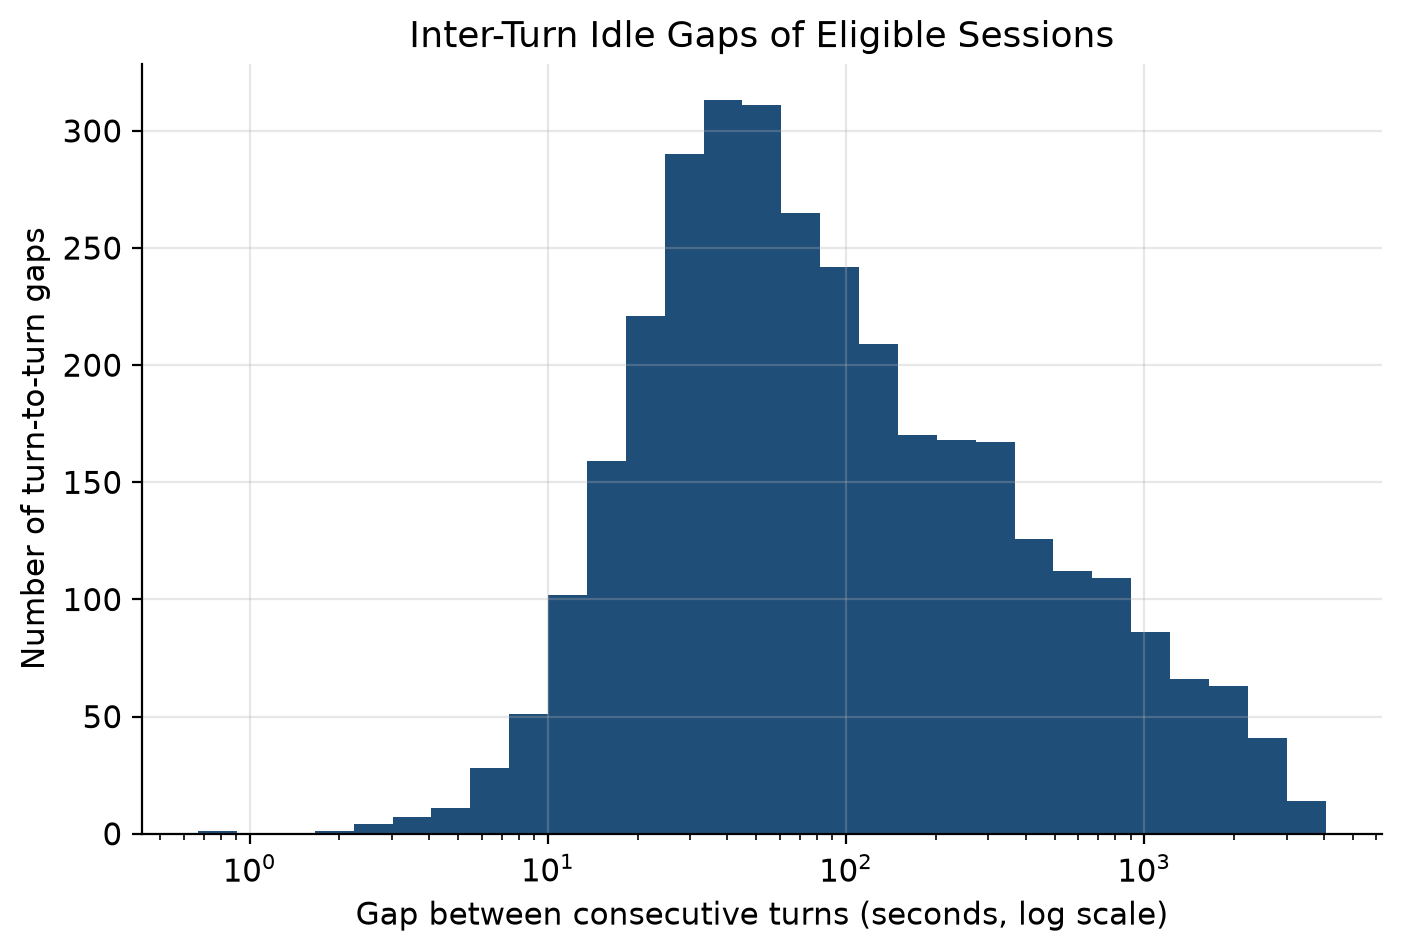

**retained sessions over time**

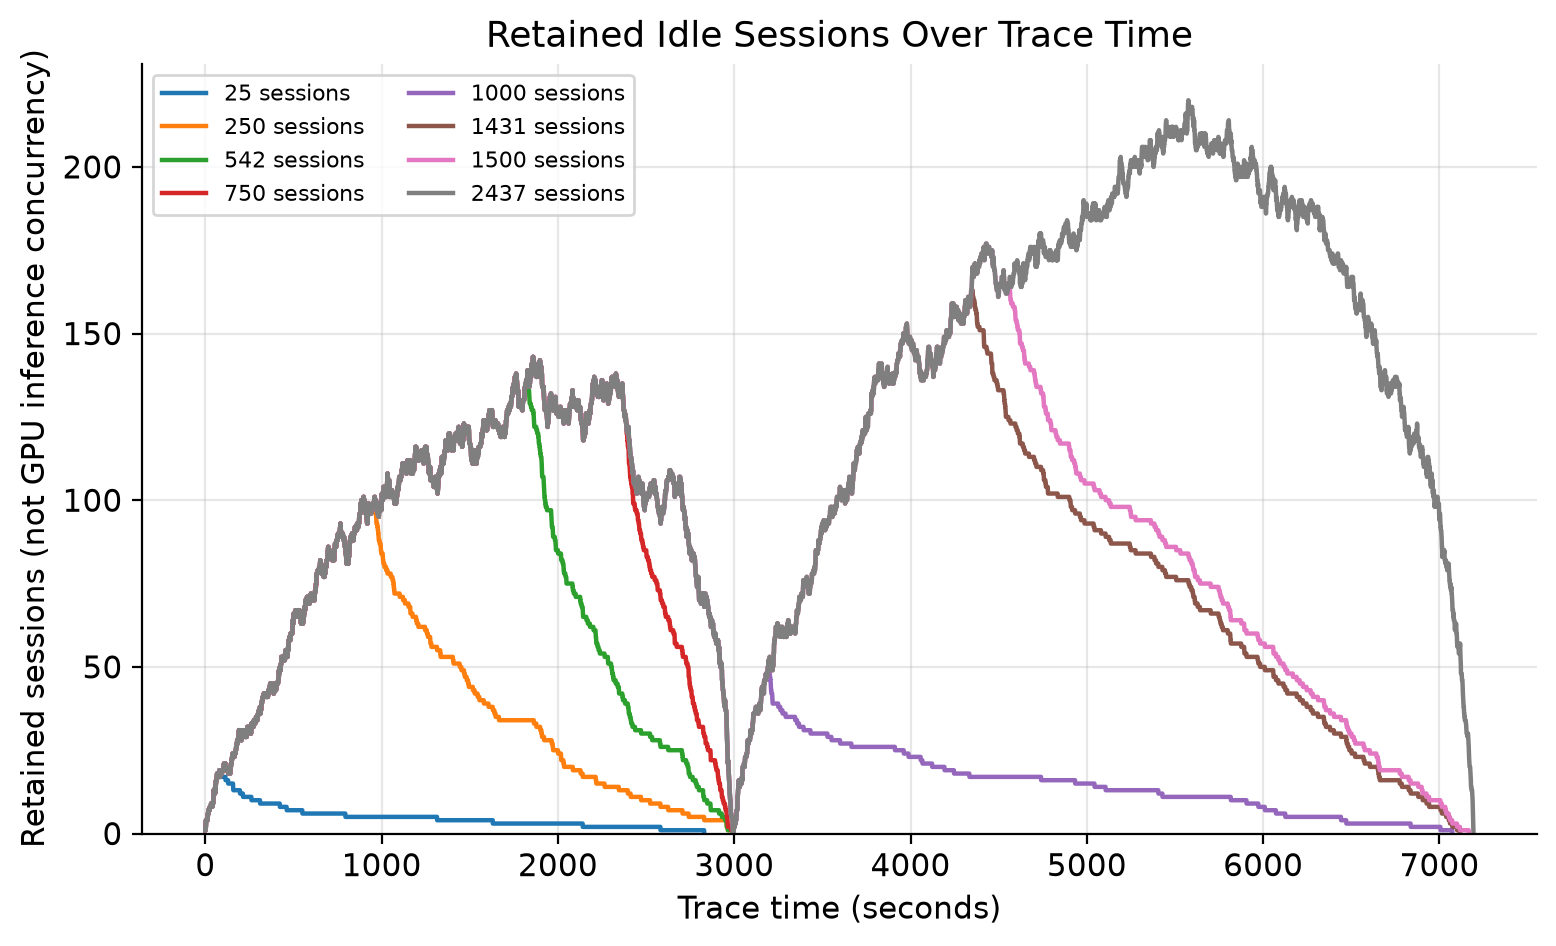

**retained hot blocks vs capacity**

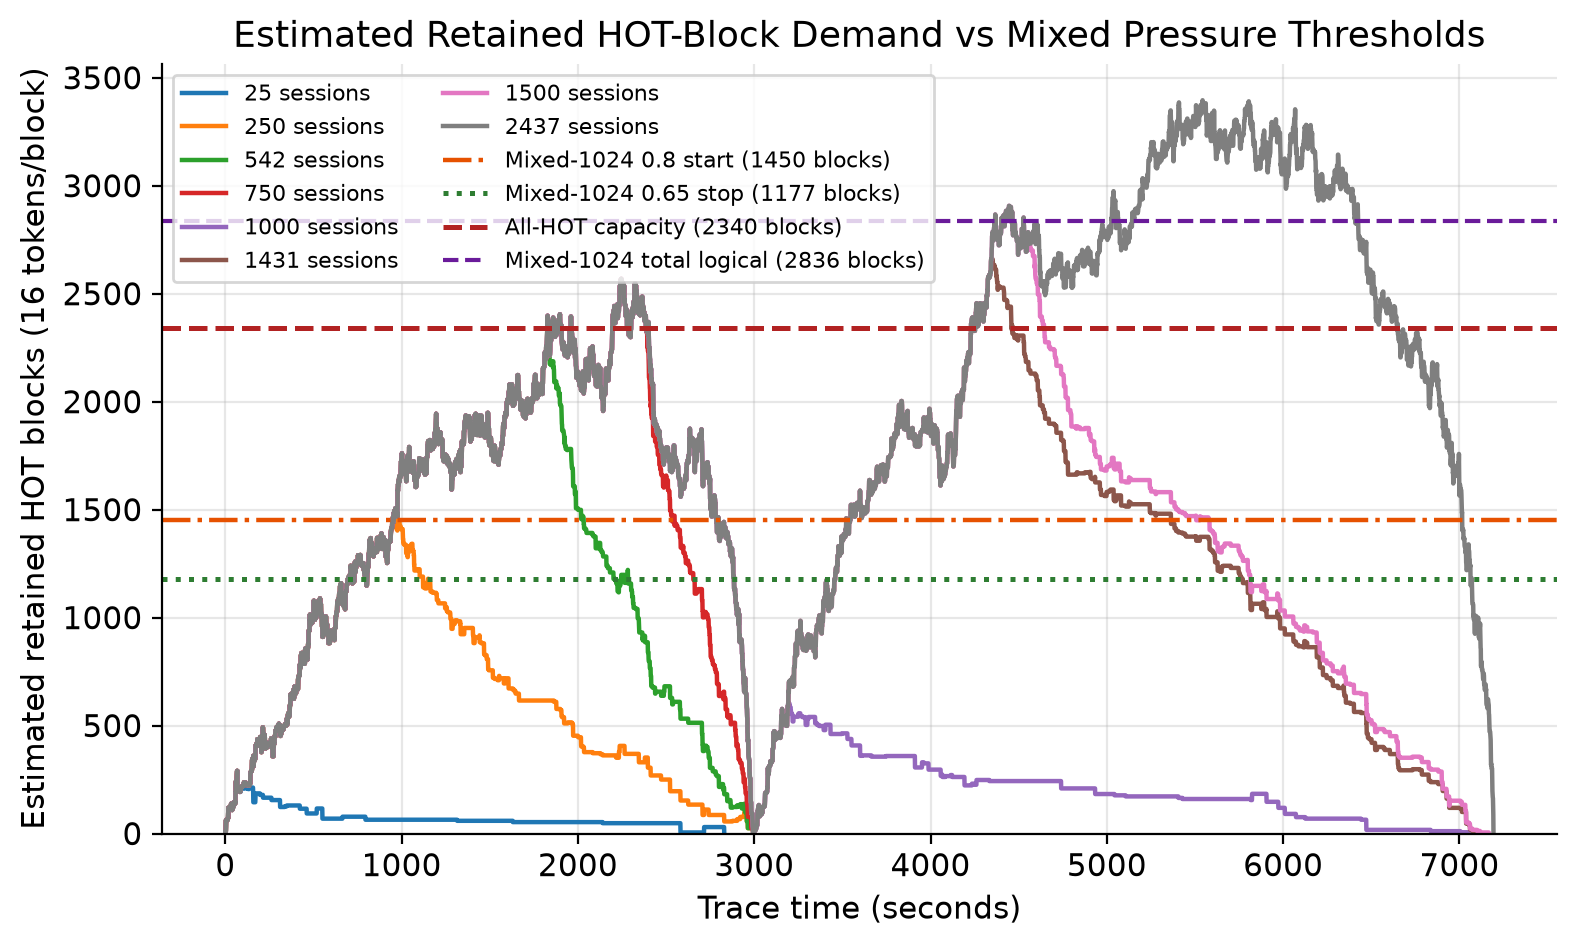

**equal memory logical capacity**

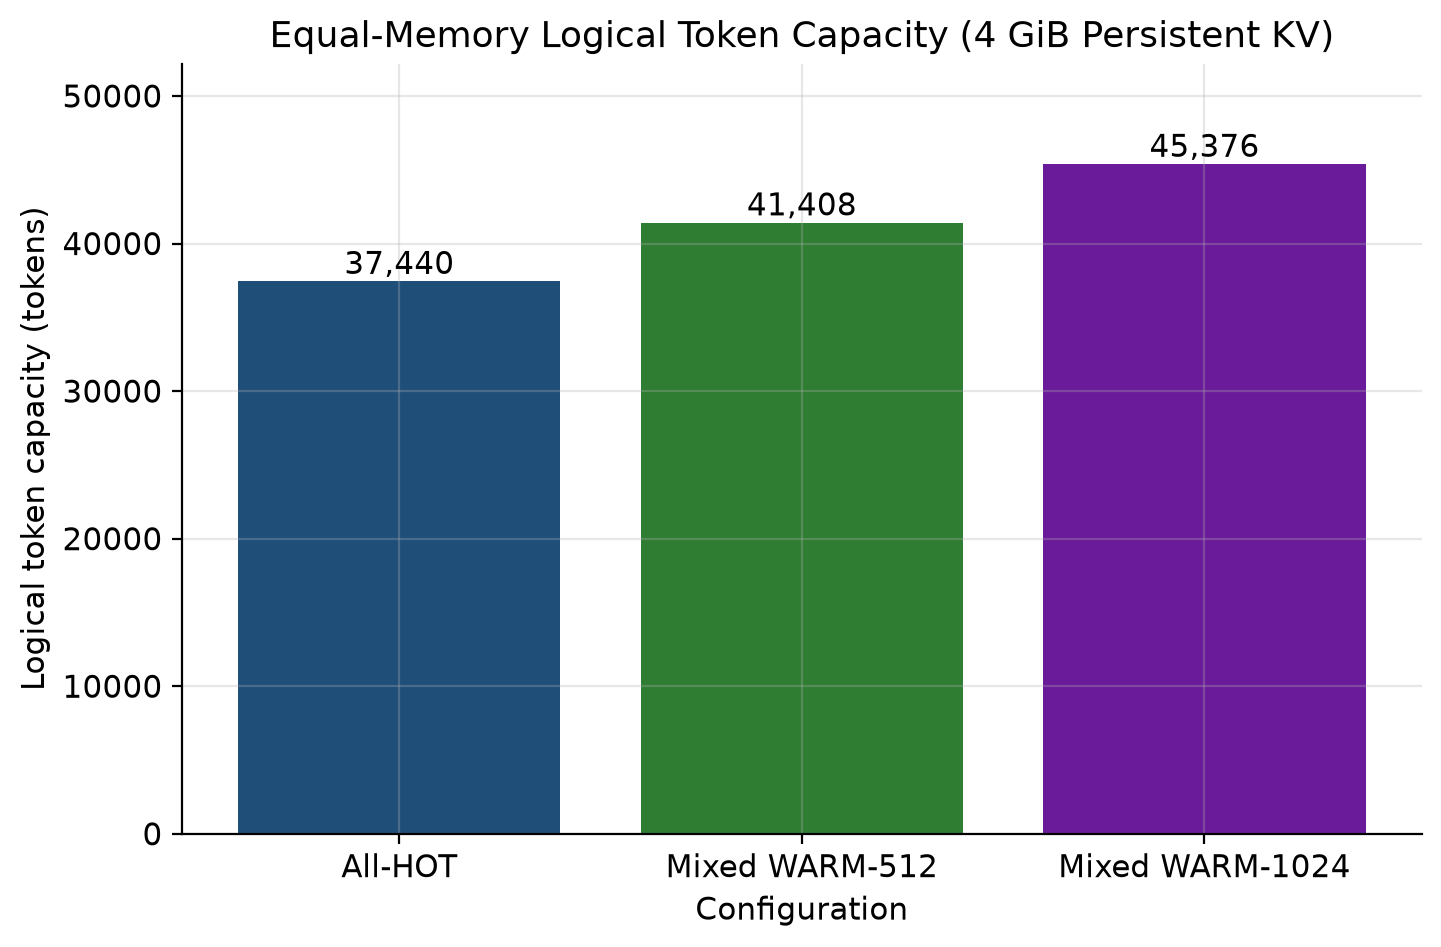

In [4]:
figure_stems = [
    "turns_per_session",
    "context_length_distribution",
    "inter_turn_gap_distribution",
    "retained_sessions_over_time",
    "retained_hot_blocks_vs_capacity",
    "equal_memory_logical_capacity",
]
stored_paths = stats.get("figure_paths", {})
for stem in figure_stems:
    png_path = FIGURES_DIR / f"{stem}.png"
    if stem in stored_paths:
        png_path = Path(stored_paths[stem]["png"])
    if not png_path.exists():
        display(Markdown(f"**Missing figure:** `{png_path}`"))
        continue
    display(Markdown(f"**{stem.replace('_', ' ')}**"))
    display(Image(filename=str(png_path)))

## 5. Interpretation

`input_length` is the **cumulative context** of a session at that turn, not the
incremental tokens added by the turn. The analysis therefore uses each session's
final input length for total context-token demand and the last arrived input
length for retained HOT occupancy. Summing per-turn input lengths would
double-count history.

The trace identifies **sessions** by root `chat_id`. It does not contain a
verified user identifier. Retained-session overlap is the number of
conversations that have started and not yet reached their final turn. That is
not GPU inference concurrency; simultaneously active decode cannot be recovered
from arrival timestamps, and measured runtime concurrency requires a GPU replay.

Uniform time scaling changes simulated arrival density and wall-clock duration.
It does **not** change which idle sessions overlap. Mixed pressure is
utilization-based: Mixed-1024 has 1,812 HOT blocks, and demotion begins at the
primary start threshold of 0.80 (`1,449/1,812 < 0.80`, `1,450/1,812 >= 0.80`).
A prefix can therefore start demotion without exhausting HOT or exceeding the
2,340-block All-HOT capacity. High-load selection looks for a timestamp-ordered
prefix whose peak retained demand is clearly above 2,340 blocks, below the
2,836-block Mixed-1024 total logical capacity, and preferably in 2,600–2,750
blocks.

In [5]:
display(Markdown("### Script recommendation"))
display(pd.DataFrame([recommendation["replay_cli_hints"]]))
policy = recommendation.get("primary_demotion_policy")
if policy:
    display(Markdown("### Primary Mixed-1024 demotion policy"))
    display(pd.DataFrame([policy]))
for line in recommendation["evidence"]:
    display(Markdown(f"- {line}"))

display(Markdown("### Caveats that remain before GPU calibration"))
for line in stats["caveats"]:
    display(Markdown(f"- {line}"))

### Script recommendation

,max_input_length,min_turns,request_type,max_sessions_smoke,max_sessions_smallest_pressure,max_sessions_medium,max_sessions_high,time_scale,fallback_time_scale,warm_pool_blocks,demotion_start_utilization,demotion_stop_utilization,total_kv_budget_bytes
0,1024,2,text,25,542,250,1431,0.01,0.005,1024,0.8,0.65,4294967296


### Primary Mixed-1024 demotion policy

,start_utilization,stop_utilization,mixed_hot_blocks,mixed_hot_start_threshold_blocks,mixed_hot_stop_target_blocks,mixed_total_logical_blocks
0,0.8,0.65,1812,1450,1177,2836


- Mixed-1024 has 1812 HOT blocks. Demotion under the primary policy begins at 1450 HOT blocks (0.8 utilization) and targets 1177 HOT blocks (0.65). 1449/1812 < 0.8 while 1450/1812 >= 0.8.

...

- Active in-flight decode cannot be recovered from arrival timestamps.

- Measured runtime concurrency requires a GPU replay.

- Retained HOT occupancy uses the last arrived cumulative prompt. Trace output tokens are already included in the next turn's input_length and are not added again.

- --seed is recorded for replay compatibility but does not change timestamp-ordered session selection.

- Mixed demotion is utilization-based. Occupancy can start demotion before the HOT pool is exhausted; the primary Mixed-1024 start threshold is 0.8 of HOT blocks.